# 🔍 SHAP Explainability — DistilBERT Resume Classifier
**Project:** Mitigating Algorithmic Bias in AI-Powered Resume Screening

Pipeline:
1. Load fine-tuned DistilBERT + dataset_clean.csv
2. Sample 20 resumes per occupation
3. SHAP analysis (shap.Explainer with text masker)
4. Save progress per occupation (resume-safe)
5. Aggregate token importance + flag proxy tokens
6. Visualisation


## 0. Imports & Config

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path

warnings.filterwarnings("ignore")

import torch
import shap
from transformers import (
    DistilBertForSequenceClassification,
    DistilBertTokenizerFast,
)
from sklearn.preprocessing import LabelEncoder

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR       = Path('/content/drive/MyDrive/CV-Screening')
MODEL_DIR      = BASE_DIR / 'model'
CLEAN_CSV      = BASE_DIR / 'dataset_clean.csv'
LABEL_MAP_CSV  = BASE_DIR / 'label_map.csv'
SHAP_DIR       = BASE_DIR / 'shap_results'          # progress saved here
SHAP_DIR.mkdir(exist_ok=True)

# ── Config ────────────────────────────────────────────────────────────────────
DEVICE         = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SAMPLES_PER_OCC = 30
SEED           = 42

# Proxy tokens to flag for bias (from proposal)
PROXY_TOKENS = [
    # universities
    "university", "college", "institute", "school", "academy",
    # zip / location
    "zip", "postal", "district", "county",
    # years of experience
    "years", "year", "experience", "experienced", "senior", "junior",
    # gender-related
    "he", "she", "him", "her", "his", "hers", "mr", "ms", "mrs", "girls", "girl", "boys", "boy", "man", "woman", "male", "female"
]

print(f"Device : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
print("Config ready ✓")


Device : cuda
GPU    : Tesla T4
Config ready ✓


## 1. Load Model & Tokenizer

In [ ]:
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
model     = DistilBertForSequenceClassification.from_pretrained(MODEL_DIR).to(DEVICE)
model.eval()

# Label map
label_map = pd.read_csv(LABEL_MAP_CSV)
id2label  = dict(zip(label_map['label'], label_map['occupation']))
NUM_CLASSES = len(id2label)

print(f"Model loaded ✓")
print(f"Classes: {NUM_CLASSES}")


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model loaded ✓
Classes: 24


## 2. Sample Dataset

In [ ]:
df_clean = pd.read_csv(CLEAN_CSV)

# Sample 20 per occupation, stratified
df_sample = (
    df_clean.groupby('occupation', group_keys=False)
    .apply(lambda x: x.sample(min(SAMPLES_PER_OCC, len(x)), random_state=SEED))
    .reset_index(drop=True)
)

print(f"Total samples : {len(df_sample)}")
print(f"Per occupation:")
print(df_sample['occupation'].value_counts().to_string())


Total samples : 712
Per occupation:
occupation
ACCOUNTANT                30
ADVOCATE                  30
AGRICULTURE               30
APPAREL                   30
ARTS                      30
AUTOMOBILE                30
AVIATION                  30
BANKING                   30
BUSINESS-DEVELOPMENT      30
CHEF                      30
CONSTRUCTION              30
CONSULTANT                30
DIGITAL-MEDIA             30
DESIGNER                  30
ENGINEERING               30
FINANCE                   30
INFORMATION-TECHNOLOGY    30
FITNESS                   30
HEALTHCARE                30
HR                        30
SALES                     30
PUBLIC-RELATIONS          30
TEACHER                   30
BPO                       22


## 3. SHAP Analysis (with Progress Saving)

In [ ]:
def predict_proba(texts):
    """Wrapper for SHAP — takes list of strings, returns probability array."""
    inputs = tokenizer(
        list(texts),
        return_tensors='pt',
        padding=True,
        truncation=True,
        max_length=512,
    ).to(DEVICE)
    with torch.no_grad():
        logits = model(**inputs).logits
    return torch.softmax(logits, dim=-1).cpu().numpy()

print("predict_proba() defined ✓")
print(f"Test shape: {predict_proba(['test resume text']).shape}")


predict_proba() defined ✓
Test shape: (1, 24)


In [ ]:
# SHAP Explainer with text masker
masker    = shap.maskers.Text(tokenizer)
explainer = shap.Explainer(predict_proba, masker, output_names=list(id2label.values()))

print("SHAP Explainer ready ✓")


SHAP Explainer ready ✓


In [ ]:
# Run SHAP per occupation — save progress after each occupation
occupations = df_sample['occupation'].unique()
print(f"Processing {len(occupations)} occupations × {SAMPLES_PER_OCC} samples")
print(f"Estimated time: ~2-3 hours on T4\n")

for occ in occupations:
    save_path = SHAP_DIR / f"shap_{occ}.json"

    # Skip if already done
    if save_path.exists():
        print(f"[skip] {occ} — already saved")
        continue

    occ_texts = df_sample[df_sample['occupation'] == occ]['text'].tolist()
    print(f"Processing: {occ} ({len(occ_texts)} samples)...", end=' ', flush=True)

    try:
        shap_values = explainer(occ_texts)

        # Save: token strings + shap values for predicted class
        results = []
        for i, text in enumerate(occ_texts):
            tokens = shap_values[i].data          # token strings
            values = shap_values[i].values        # shape: (n_tokens, n_classes)

            # Get predicted class index
            pred_class_idx = predict_proba([text]).argmax()

            results.append({
                'filename':   df_sample[df_sample['occupation'] == occ].iloc[i]['filename'],
                'occupation': occ,
                'tokens':     tokens.tolist() if hasattr(tokens, 'tolist') else list(tokens),
                'shap_values': values[:, pred_class_idx].tolist(),
                'pred_class': id2label[pred_class_idx],
            })

        with open(save_path, 'w') as f:
            json.dump(results, f)

        print(f"✓ saved → {save_path.name}")

    except Exception as e:
        print(f"✗ error: {e}")

print("\nSHAP analysis complete ✓")


Processing 24 occupations × 30 samples
Estimated time: ~2-3 hours on T4

[skip] ACCOUNTANT — already saved
[skip] ADVOCATE — already saved
[skip] AGRICULTURE — already saved
[skip] APPAREL — already saved
[skip] ARTS — already saved
[skip] AUTOMOBILE — already saved
[skip] AVIATION — already saved
[skip] BANKING — already saved
[skip] BPO — already saved
[skip] BUSINESS-DEVELOPMENT — already saved
[skip] CHEF — already saved
[skip] CONSTRUCTION — already saved
[skip] CONSULTANT — already saved
[skip] DESIGNER — already saved
[skip] DIGITAL-MEDIA — already saved
[skip] ENGINEERING — already saved
[skip] FINANCE — already saved
[skip] FITNESS — already saved
[skip] HEALTHCARE — already saved
[skip] HR — already saved
[skip] INFORMATION-TECHNOLOGY — already saved
[skip] PUBLIC-RELATIONS — already saved
[skip] SALES — already saved
[skip] TEACHER — already saved

SHAP analysis complete ✓


## 4. Load & Aggregate SHAP Results

In [ ]:
import re

# Load all saved SHAP results
all_records = []
for save_path in sorted(SHAP_DIR.glob("shap_*.json")):
    with open(save_path) as f:
        all_records.extend(json.load(f))

print(f"Total records loaded: {len(all_records)}")

MONTHS = {'jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec'}

ROMAN = {'i','ii','iii','iv','v','vi','vii','viii','ix','x',
         'xi','xii','xiii','xiv','xv','xvi','xvii','xviii','xix','xx'}

def merge_tokens(tokens, shap_values):
    merged_tokens = []
    merged_values = []
    buffer_token  = ""
    buffer_values = []

    for token, value in zip(tokens, shap_values):
        buffer_token += token
        buffer_values.append(value)

        if token.endswith(" ") or token in [",", ".", "!", "?"]:
            merged_tokens.append(buffer_token.strip())
            merged_values.append(np.mean(buffer_values))
            buffer_token  = ""
            buffer_values = []

    if buffer_token.strip():
        merged_tokens.append(buffer_token.strip())
        merged_values.append(np.mean(buffer_values))

    return merged_tokens, merged_values


rows = []
for rec in all_records:
    tokens, shap_vals = merge_tokens(rec['tokens'], rec['shap_values'])
    for token, shap_val in zip(tokens, shap_vals):
        token_clean = token.strip().lower().rstrip(".,!?-")

        if not token_clean:
            continue
        if token_clean in ['[cls]', '[sep]', '[pad]']:
            continue
        if len(token_clean) < 3:
            continue
        if token_clean.isdigit():
            continue
        if token_clean in MONTHS:
            continue
        if token_clean in ROMAN:
            continue

        rows.append({
            'occupation': rec['occupation'],
            'filename':   rec['filename'],
            'token':      token_clean,
            'shap_value': shap_val,
            'is_proxy':   token_clean in PROXY_TOKENS,
        })

df_shap = pd.DataFrame(rows)
print(f"Token-level records: {len(df_shap):,}")
print(df_shap.head(10))

Total records loaded: 712
Token-level records: 502,182
   occupation      filename          token  shap_value  is_proxy
0  ACCOUNTANT  23636277.txt     accountant    0.041390     False
1  ACCOUNTANT  23636277.txt        summary    0.041390     False
2  ACCOUNTANT  23636277.txt        achieve    0.009938     False
3  ACCOUNTANT  23636277.txt            job    0.009938     False
4  ACCOUNTANT  23636277.txt     accountant    0.020528     False
5  ACCOUNTANT  23636277.txt           that    0.020528     False
6  ACCOUNTANT  23636277.txt       utilizes    0.020528     False
7  ACCOUNTANT  23636277.txt     accounting    0.017379     False
8  ACCOUNTANT  23636277.txt  communication   -0.001037     False
9  ACCOUNTANT  23636277.txt     analytical   -0.001037     False


## 5. Top Tokens per Occupation

In [ ]:
# Aggregate mean absolute SHAP value per token per occupation
df_agg = (
    df_shap.groupby(['occupation', 'token', 'is_proxy'])['shap_value']
    .agg(mean_abs=lambda x: np.abs(x).mean(), mean=np.mean)
    .reset_index()
    .sort_values(['occupation', 'mean_abs'], ascending=[True, False])
)

# Save aggregated results
df_agg.to_csv(BASE_DIR / 'shap_aggregated.csv', index=False)
print(f"Saved: shap_aggregated.csv")
print(f"\nTop 5 tokens per occupation:")
print(df_agg.groupby('occupation').head(5).to_string(index=False))


Saved: shap_aggregated.csv

Top 5 tokens per occupation:
            occupation             token  is_proxy  mean_abs     mean
            ACCOUNTANT        innovative     False  0.024688 0.024688
            ACCOUNTANT          emerging     False  0.024447 0.024447
            ACCOUNTANT           skilled     False  0.024091 0.024091
            ACCOUNTANT           summary     False  0.023868 0.023868
            ACCOUNTANT          utilizes     False  0.020528 0.020528
              ADVOCATE       fulfillment     False  0.028553 0.028553
              ADVOCATE            intern     False  0.023268 0.023268
              ADVOCATE      transitional     False  0.021153 0.021153
              ADVOCATE           respect     False  0.019481 0.019481
              ADVOCATE          advocate     False  0.018944 0.018944
           AGRICULTURE            worker     False  0.063397 0.063397
           AGRICULTURE        harvesting     False  0.034358 0.034358
           AGRICULTURE           

## 6. Proxy Token Flagging

In [ ]:
# Proxy tokens with high SHAP values → potential bias indicators
proxy_flags = df_agg[df_agg['is_proxy'] == True].copy()
proxy_flags = proxy_flags.sort_values('mean_abs', ascending=False)

print(f"Proxy tokens detected: {len(proxy_flags)}")
print(f"\nTop proxy tokens by SHAP importance:")
print(proxy_flags[['occupation', 'token', 'mean_abs', 'mean']].head(20).to_string(index=False))

# Save flagged proxies
proxy_flags.to_csv(BASE_DIR / 'shap_proxy_flags.csv', index=False)
print(f"\nSaved: shap_proxy_flags.csv")


Proxy tokens detected: 386

Top proxy tokens by SHAP importance:
            occupation       token  mean_abs      mean
            CONSULTANT      female  0.014535  0.014535
            CONSULTANT experienced  0.014253  0.014253
               TEACHER experienced  0.012069  0.012069
           ENGINEERING      senior  0.009925  0.009864
            ACCOUNTANT experienced  0.009632  0.009632
              DESIGNER      senior  0.007837  0.007830
            HEALTHCARE experienced  0.007039  0.007039
           ENGINEERING  experience  0.006337  0.006233
          CONSTRUCTION      senior  0.006147  0.006147
              DESIGNER  experience  0.005911  0.005911
      PUBLIC-RELATIONS experienced  0.005897  0.005897
INFORMATION-TECHNOLOGY  experience  0.005346  0.005345
              DESIGNER        boys  0.005141 -0.005141
               FINANCE  experience  0.004947  0.004338
                  CHEF      senior  0.004556  0.004481
            CONSULTANT     college  0.004533  0.004252


## 7. Visualisation

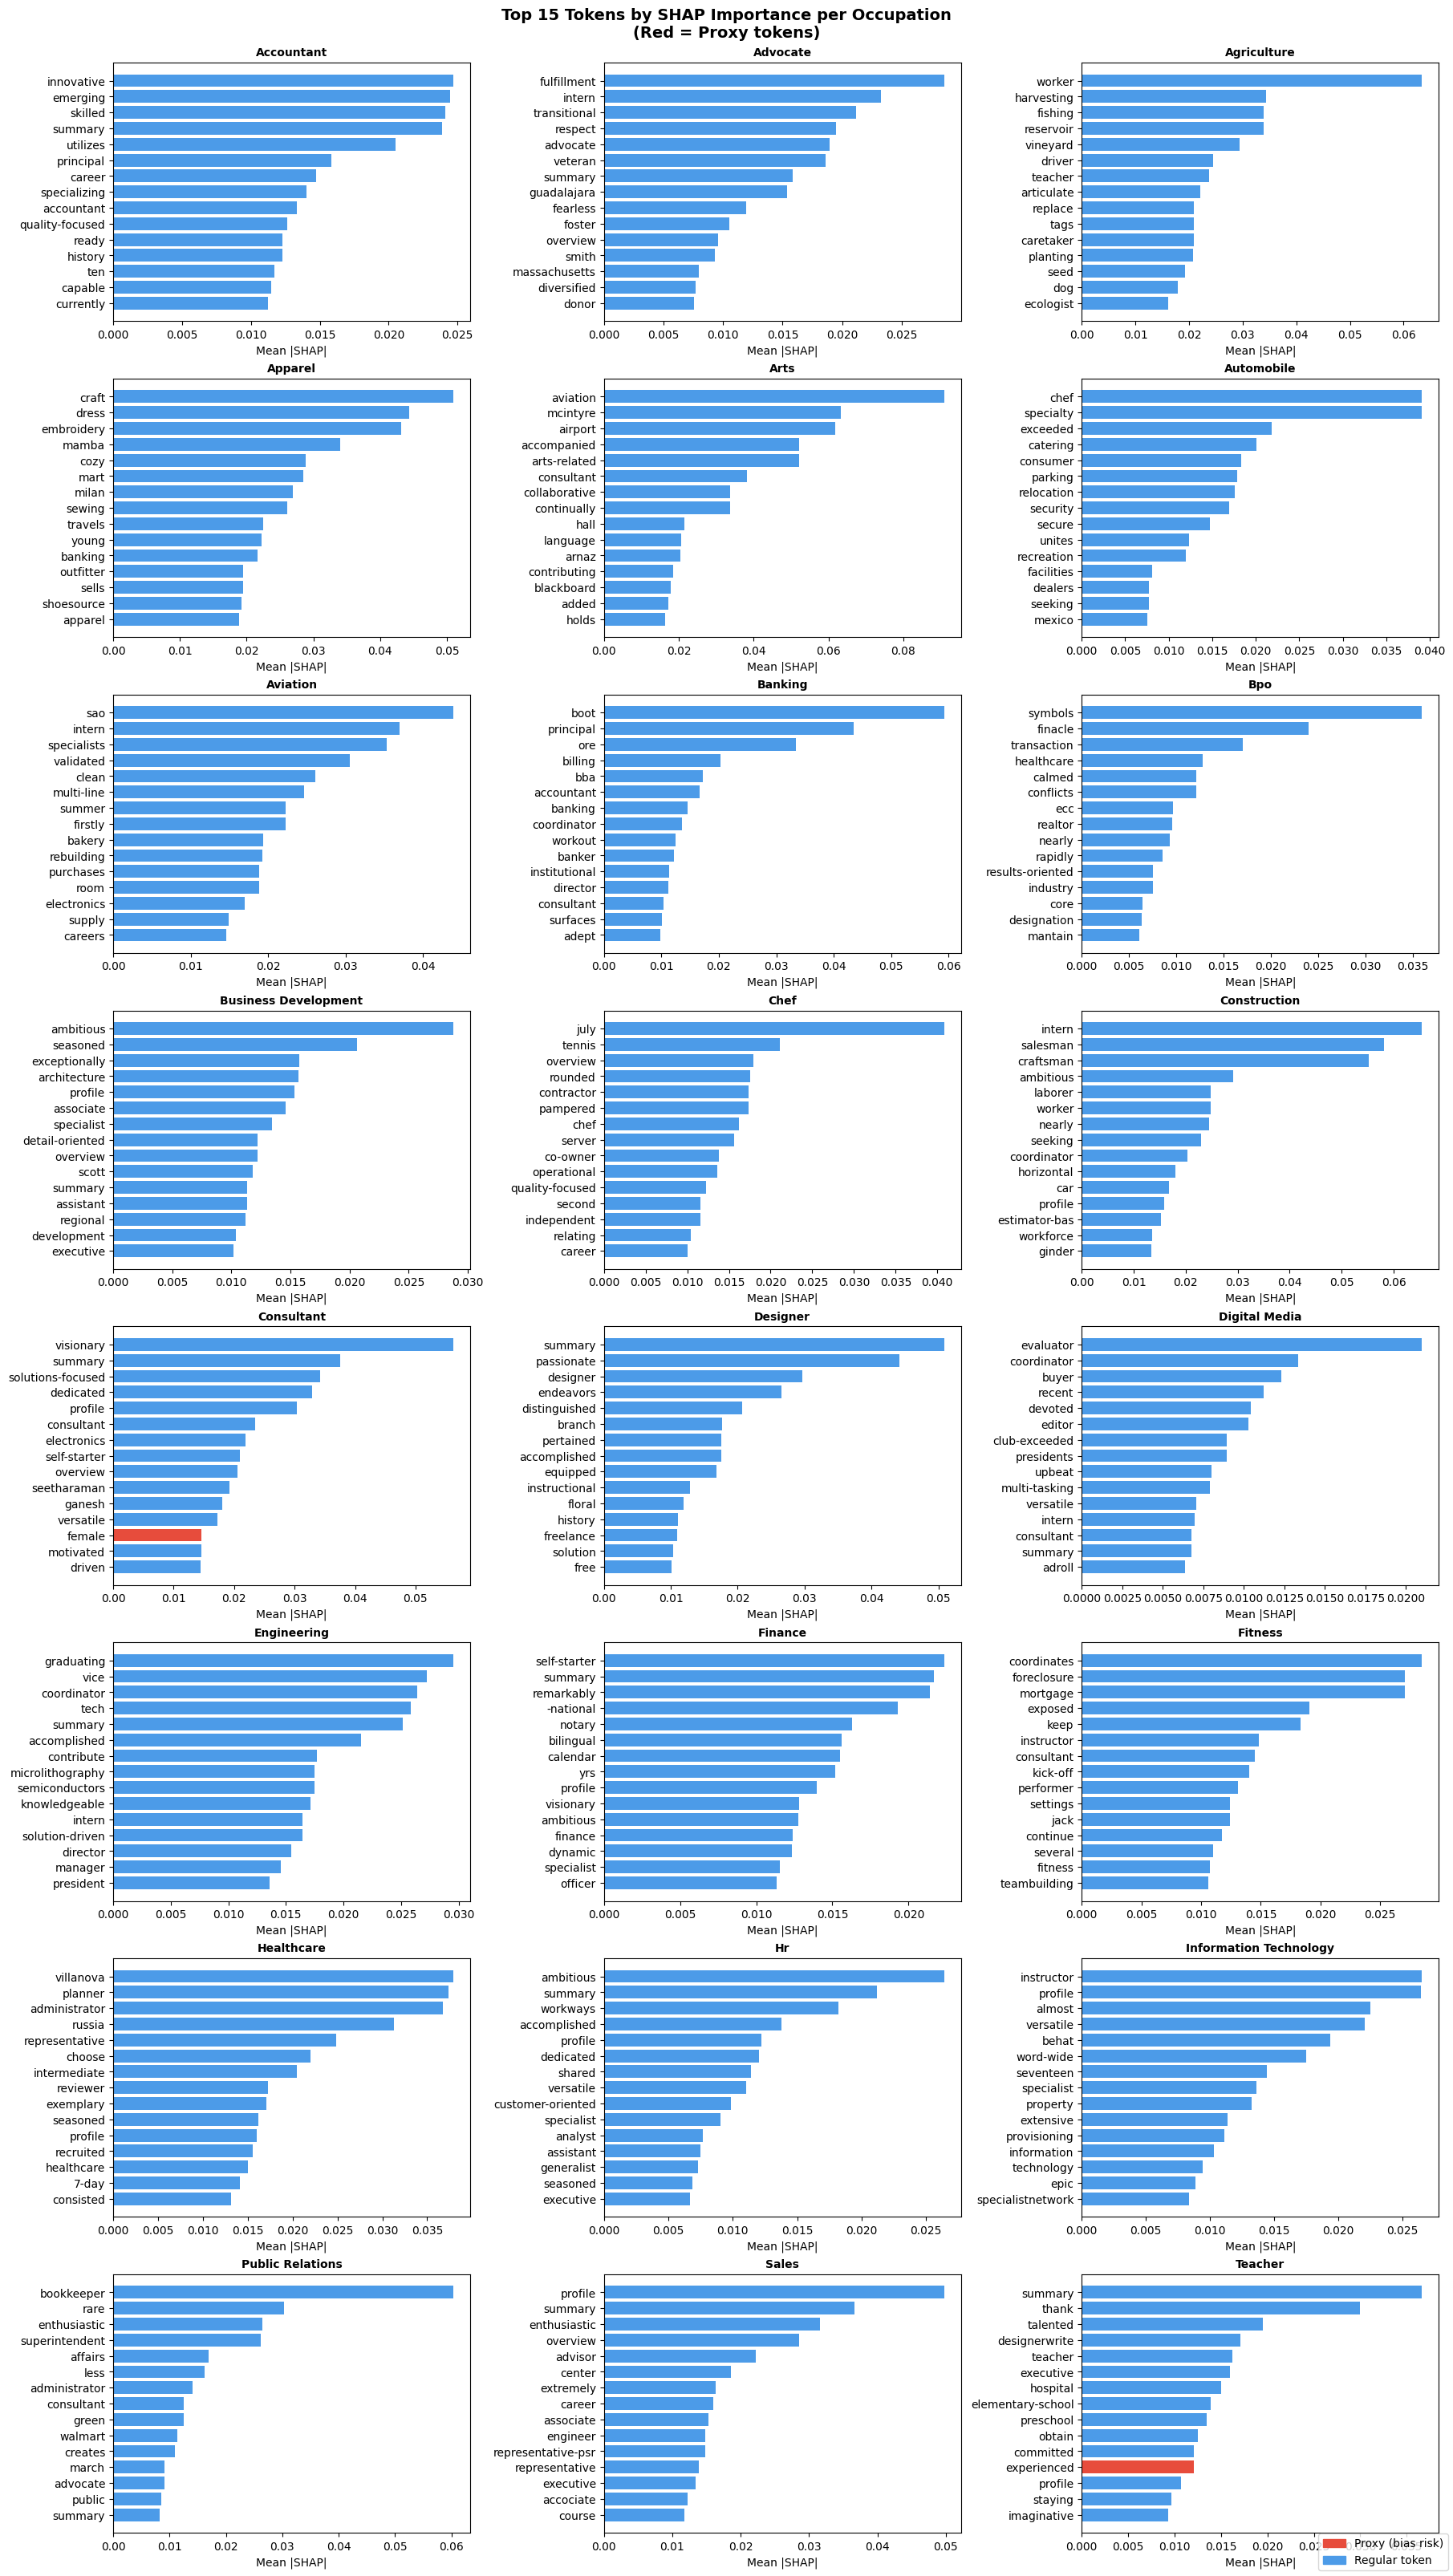

Saved: shap_top_tokens.png


In [ ]:
# Top 15 tokens per occupation (proxy tokens highlighted in red)
occupations = df_agg['occupation'].unique()
cols = 3
rows = (len(occupations) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows), constrained_layout=True)
axes = np.array(axes).flatten()

for ax, occ in zip(axes, occupations):
    top = df_agg[df_agg['occupation'] == occ].head(15)
    colors = ['#e74c3c' if p else '#4C9BE8' for p in top['is_proxy']]
    ax.barh(top['token'][::-1], top['mean_abs'][::-1], color=colors[::-1])
    ax.set_title(occ.replace('-', ' ').title(), fontsize=10, fontweight='bold')
    ax.set_xlabel('Mean |SHAP|')

for ax in axes[len(occupations):]:
    ax.axis('off')

# Legend
from matplotlib.patches import Patch
legend = [Patch(color='#e74c3c', label='Proxy (bias risk)'),
          Patch(color='#4C9BE8', label='Regular token')]
fig.legend(handles=legend, loc='lower right', fontsize=10)
plt.suptitle('Top 15 Tokens by SHAP Importance per Occupation\n(Red = Proxy tokens)',
             fontsize=14, fontweight='bold')
# plt.tight_layout()
plt.savefig(BASE_DIR / 'shap_top_tokens.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_top_tokens.png")


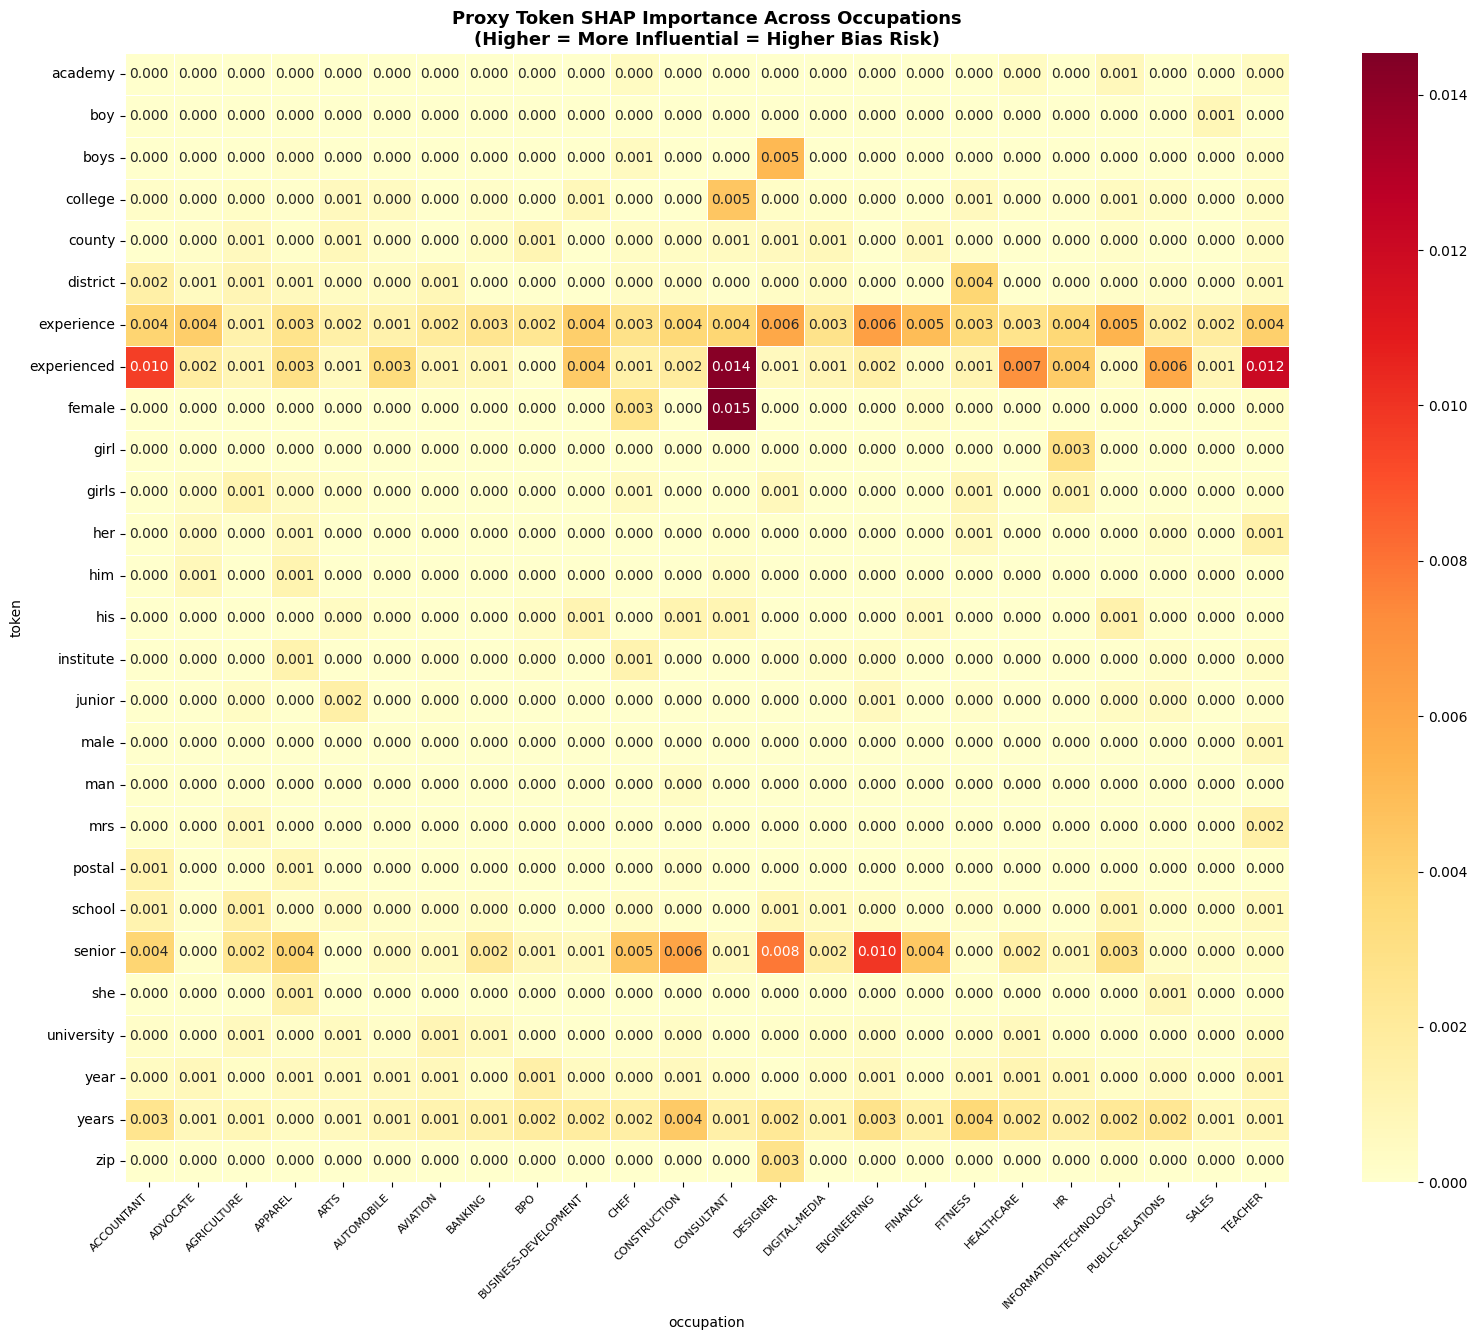

Saved: shap_proxy_heatmap.png


In [ ]:
# Heatmap: proxy token SHAP importance across occupations
pivot = proxy_flags.pivot_table(
    index='token', columns='occupation', values='mean_abs', fill_value=0
)

# Keep only tokens that appear in at least 3 occupations
pivot = pivot[pivot.gt(0).sum(axis=1) >= 3]

if not pivot.empty:
    fig, ax = plt.subplots(figsize=(16, max(6, len(pivot) * 0.5)))
    sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.3f',
                linewidths=0.5, ax=ax)
    ax.set_title('Proxy Token SHAP Importance Across Occupations\n(Higher = More Influential = Higher Bias Risk)',
                 fontsize=13, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.tight_layout()
    plt.savefig(BASE_DIR / 'shap_proxy_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: shap_proxy_heatmap.png")
else:
    print("No proxy tokens appear in 3+ occupations — lower threshold if needed")


## 8. Summary

In [ ]:
print("=" * 55)
print("  SHAP EXPLAINABILITY SUMMARY")
print("=" * 55)
print(f"  Occupations analyzed : {df_shap['occupation'].nunique()}")
print(f"  Total token records  : {len(df_shap):,}")
print(f"  Proxy tokens flagged : {len(proxy_flags)}")
print(f"  High-risk proxies    : {len(proxy_flags[proxy_flags['mean_abs'] > 0.01])}")
print("=" * 55)
print()
print("Output files:")
print(f"  shap_results/        → raw SHAP per occupation (resume-safe)")
print(f"  shap_aggregated.csv  → token-level SHAP aggregated")
print(f"  shap_proxy_flags.csv → proxy tokens with SHAP scores → input to fairness.ipynb")
print(f"  shap_top_tokens.png  → visualisation")
print(f"  shap_proxy_heatmap.png → proxy bias heatmap")
print()
print("Next: fairness.ipynb ← load shap_proxy_flags.csv")


  SHAP EXPLAINABILITY SUMMARY
  Occupations analyzed : 24
  Total token records  : 502,182
  Proxy tokens flagged : 386
  High-risk proxies    : 3

Output files:
  shap_results/        → raw SHAP per occupation (resume-safe)
  shap_aggregated.csv  → token-level SHAP aggregated
  shap_proxy_flags.csv → proxy tokens with SHAP scores → input to fairness.ipynb
  shap_top_tokens.png  → visualisation
  shap_proxy_heatmap.png → proxy bias heatmap

Next: fairness.ipynb ← load shap_proxy_flags.csv
